<a href="https://colab.research.google.com/github/karimamzghi/cifar10-cnn-classification-project/blob/main/baseline_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 - CNN Image Classification

# ***Model 1: Baseline CNN using CIFAR-10 DataSet***

In [ ]:
%cd /content
import os

if not os.path.exists("/content/cifar10-cnn-classification-project"):
    !git clone https://github.com/karimamzghi/cifar10-cnn-classification-project.git

%cd /content/cifar10-cnn-classification-project

from google.colab import drive
drive.mount("/content/drive")

In [21]:
# Import numpy lib
import importlib

import numpy as np

# Imports matptotlib lib
import matplotlib.pyplot as plt

# Imports tensorflow.Keras lib
import keras as keras
from keras import layers
from keras.backend import clear_session
from keras.optimizers import SGD

# Imports seaborn lib
import seaborn as sns

# Imports sklearn lib
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix

import importlib

from src import config

import src.training.trainer as trainer
import src.training.evaluator as evaluator
import src.data_loader as data_loader

importlib.reload(trainer)
importlib.reload(evaluator)
importlib.reload(data_loader)
importlib.reload(config)

# Imports custom files aka config, experiment files, etc
from src.training.trainer import compile_model, train_model, save_model
from src.training.evaluator import (
    evaluate_model,
    get_predictions,
    calculate_precision_recall,
    save_confusion_matrix
)
from src.data_loader import load_data
from src.experiment_tracker import save_experiment_results    


ImportError: cannot import name 'compile_model' from 'src.training.trainer' (/content/cifar10-cnn-classification-project/src/training/trainer.py)

In [ ]:
# ── One-time: load, preprocess, and save CIFAR-10 to Drive ──
import os
import numpy as np
from tensorflow.keras.datasets import cifar10
from src import config

# 1. Load raw data (downloads ~170 MB on first run)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Preprocess — same steps your pipeline uses
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Save to Drive
os.makedirs(config.DATA_DIR, exist_ok=True)

np.save(os.path.join(config.DATA_DIR, "x_train.npy"), x_train)
np.save(os.path.join(config.DATA_DIR, "y_train.npy"), y_train)
np.save(os.path.join(config.DATA_DIR, "x_test.npy"), x_test)
np.save(os.path.join(config.DATA_DIR, "y_test.npy"), y_test)

print("Saved to:", config.DATA_DIR)
print(f"x_train: {x_train.shape} | y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape} | y_test:  {y_test.shape}")

Saved to: ./data/processed
x_train: (50000, 32, 32, 3) | y_train: (50000, 1)
x_test:  (10000, 32, 32, 3) | y_test:  (10000, 1)


In [ ]:
!grep "^def " src/training/trainer.py


In [ ]:
MODEL_ID = 1
MODEL_NAME = "baseline_cnn"

In [ ]:
# Load the data fromm cache using the load_data function from data_loader.py
x_train, y_train, x_val, y_val, x_test, y_test = load_data()

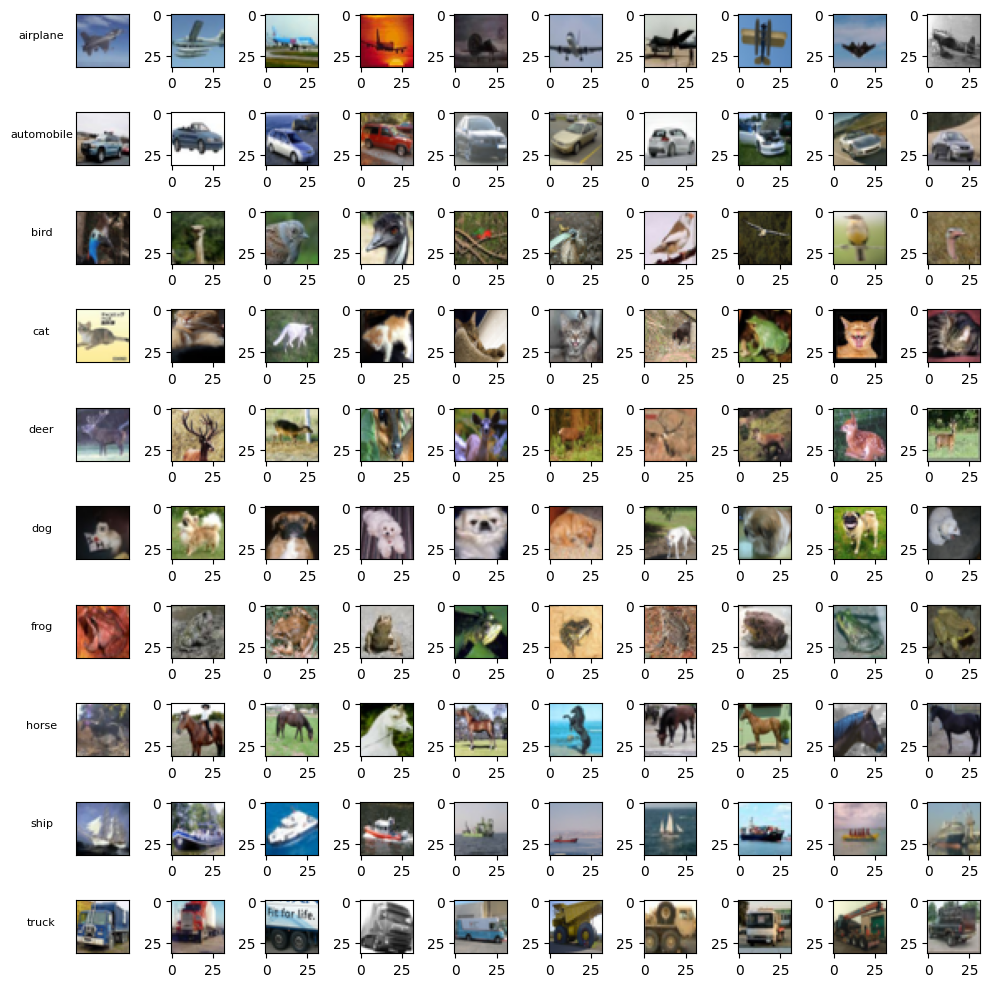

In [ ]:
# Add image visualization utilities
labels = np.argmax(y_train, axis=1)   # one-hot (N,10) -> integer (N,)

plt.figure(figsize=(10, 10))

for class_id in range(10):
    class_indices = np.where(labels == class_id)[0]
    for sample_idx in range(10):
        position = (class_id * 10) + sample_idx + 1
        img_index = class_indices[sample_idx]

        plt.subplot(10, 10, position)
        plt.imshow(x_train[img_index])
                      
    # Label each row with its class name
    plt.subplot(10, 10, class_id * 10 + 1)
    plt.ylabel(config.CLASS_NAMES[class_id], fontsize=8, rotation=0,
               labelpad=25)
    plt.yticks([]); plt.xticks([])

plt.tight_layout()
plt.show()

In [ ]:
# Clear any previous TensorFlow models from memory as TensorFlow can accumulate unnecessary objects in memory,
# especially if we are creating many models while tuning hyperparameters.
clear_session()

In [ ]:
# Build the Baseline CNN Model

# Initialize and define the model
baseline_model = keras.Sequential(
    [
        keras.Input(shape=config.INPUT_SHAPE),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(64, activation="relu"),
        layers.Dense(config.NUM_CLASSES, activation="softmax"),
    ],
    name="baseline_cnn"
)

# Display the model params
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%writefile /content/cifar10-cnn-classification-project/src/training/trainer.py


Overwriting /content/cifar10-cnn-classification-project/src/training/trainer.py


In [ ]:
# Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric
optimizer = keras.optimizers.SGD(
    learning_rate=config.LEARNING_RATE
)

baseline_model = compile_model(
    model=baseline_model,
    optimizer=optimizer,
    loss=config.CATEGORICAL_CROSSENTROPY,
    metrics=[config.ACCURACY]
)

In [ ]:
# Train the model using the training data and validate it using the validation data
history, train_time = train_model(
    model=baseline_model,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    batch_size=config.BATCH_SIZE,
    epochs=config.EPOCHS
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.1473 - loss: 2.2874 - val_accuracy: 0.1770 - val_loss: 2.2759
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1878 - loss: 2.2637 - val_accuracy: 0.1996 - val_loss: 2.2493
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2103 - loss: 2.2316 - val_accuracy: 0.2239 - val_loss: 2.2090
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2334 - loss: 2.1826 - val_accuracy: 0.2432 - val_loss: 2.1518
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2474 - loss: 2.1215 - val_accuracy: 0.2476 - val_loss: 2.0877
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2592 - loss: 2.0642 - val_accuracy: 0.2752 - val_loss: 2.0366
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2711 - loss: 2.0231 - val_accuracy: 0.2782 - val_loss: 2.0031
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2830 - loss: 1.9943 - val_accuracy: 0.

In [ ]:
# Sanity check: confirm we're using the new 70/15/15 split (15% of 60,000 = 9,000) and not the original Keras default test set (10,000)
print("x_test shape:", x_test.shape)
print("Expected: ~9000 (15% of 60000)")

# Evaluate the baseline model on the held-out test set 
test_loss, test_accuracy = evaluate_model(
    model=baseline_model,
    x_test=x_test,
    y_test=y_test
)

test_labels, test_predictions, y_pred_probs = get_predictions(
    model=baseline_model,
    x_test=x_test,
    y_test=y_test
)

precision, recall = calculate_precision_recall(
    test_labels=test_labels,
    test_predictions=test_predictions
)

print("\n Test accuracy:", test_accuracy)
print("Precision:", precision)
print("Recall:", recall)

x_test shape: (9000, 32, 32, 3)
Expected: ~9000 (15% of 60000)
x_test shape: (9000, 32, 32, 3)
Expected: ~9000 (15% of 60000)

Test loss: 1.7357314825057983
Test accuracy: 0.39055556058883667
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Precision: 0.3858  Recall: 0.3906

 Test accuracy: 0.39055556058883667
Precision: 0.3857796724518482
Recall: 0.39055555555555554


In [ ]:
# Save the model under the models directory defined in config.py
model_path = save_model(
    model=baseline_model,
    model_name=f"model_{MODEL_ID}_{MODEL_NAME}",
    models_dir=config.MODELS_DIR
)

Model saved to: ./models/model_1_baseline_cnn.keras


In [ ]:
import importlib
import src.training.evaluator as evaluator

importlib.reload(evaluator)

save_confusion_matrix = evaluator.save_confusion_matrix

import inspect
print(inspect.getsource(save_confusion_matrix))

def save_confusion_matrix(test_labels, test_predictions, output_path, title):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    cm = confusion_matrix(test_labels, test_predictions)

    ax = plt.subplots(figsize=(10, 10))

    # Create a ConfusionMatrixDisplay object and plot the confusion matrix
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=config.CLASS_NAMES
    )

    # Plot the confusion matrix
    display.plot(
        ax=ax,
        values_format="d",
        xticks_rotation=45
    )

    plt.title(plt.title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Save the confusion matrix plot to the specified output path
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

    return output_path



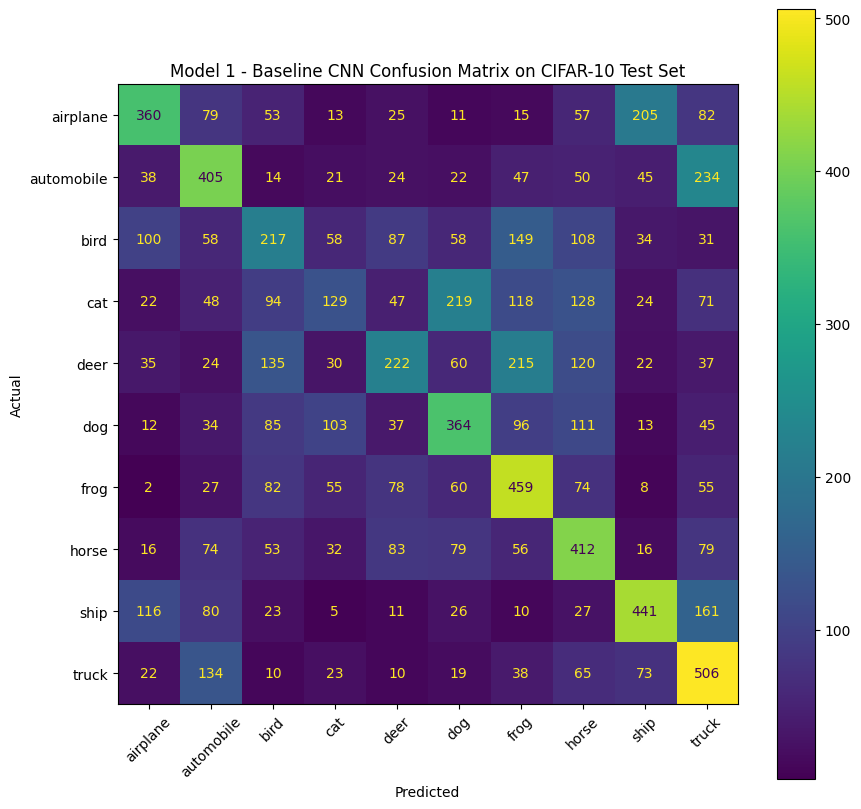

'./results/confusion_matrices/model_1_baseline_cnn_confusion_matrix.png'

In [ ]:
# Draw the confusion matrix for the test set predictions
confusion_matrix_path = (
    f"{config.CONFUSION_DIR}/model_{MODEL_ID}_{MODEL_NAME}_confusion_matrix.png"
)

save_confusion_matrix(
    test_labels=test_labels,
    test_predictions=test_predictions,
    output_path=confusion_matrix_path,
    title=f"Model {MODEL_ID} - Baseline CNN Confusion Matrix on CIFAR-10 Test Set"
)

In [ ]:
# Save the experiment results to a CSV file for tracking and analysis
experiment = {
    "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "description": "First baseline CNN model",
    "architecture": "Conv2D(32) + MaxPool + Conv2D(64) + MaxPool + Dense(64)",
    "optimizer": "SGD",
    "learning_rate": config.LEARNING_RATE,
    "batch_size": config.BATCH_SIZE,
    "epochs": len(history.history["accuracy"]),
    "train_accuracy": history.history["accuracy"][-1],
    "validation_accuracy": history.history["val_accuracy"][-1],
    "test_accuracy": test_accuracy,
    "precision": precision,
    "recall": recall,
    "train_loss": history.history["loss"][-1],
    "validation_loss": history.history["val_loss"][-1],
    "test_loss": test_loss,
    "train_time_seconds": train_time,
    "model_path": model_path,
    "confusion_matrix_path": confusion_matrix_path,
    "notes": "First baseline CNN model"
}

results_df = save_experiment_results(
    experiment,
    config.RESULTS_PATH
)

results_df

,model_id,model_name,architecture,augmentation,transfer_learning,optimizer,learning_rate,batch_size,epochs,train_accuracy,...,train_loss,validation_loss,test_loss,model_path,confusion_matrix_path,notes,description,precision,recall,train_time_seconds
0,1,baseline_cnn,Conv2D(32) + MaxPool + Conv2D(64) + MaxPool + ...,No,No,SGD,0.001,64,20,0.379071,...,1.782614,1.779500,1.782990,models/baseline_cnn.keras,results/confusion_matrices/model_1_baseline_cn...,Baseline CNN trained from scratch using SGD op...,NaN,NaN,NaN,NaN
1,1,baseline_cnn,Conv2D(32) + MaxPool + Conv2D(64) + MaxPool + ...,NaN,NaN,SGD,0.001,64,20,0.387929,...,1.748899,1.735447,1.735731,./models/model_1_baseline_cnn.keras,./results/confusion_matrices/model_1_baseline_...,First baseline CNN model,First baseline CNN model,0.38578,0.390556,64.3


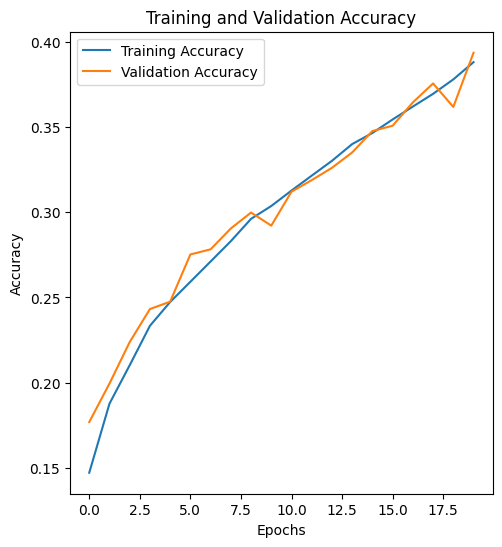

Accuracy curves saved to: ./results/plots/Model_1_baseline_cnn_accuracy_curves.png


In [ ]:
# draw a plot of the training and validation accuracy over epochs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Save the plot of the training and validation accuracy over epochs
os.makedirs(config.PLOTS_DIR, exist_ok=True)
accuracy_curves_path = (f"{config.PLOTS_DIR}/Model_{MODEL_ID}_{MODEL_NAME}_accuracy_curves.png")
plt.savefig(accuracy_curves_path, bbox_inches="tight")
plt.show()

print("Accuracy curves saved to:", accuracy_curves_path)

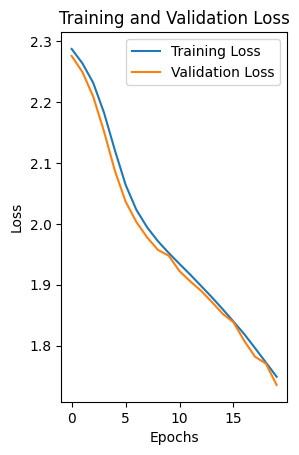

Loss curves saved to: ./results/plots/Model_1_baseline_cnn_loss_curves.png


In [ ]:
# Draw the training and validation loss over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')    
plt.ylabel('Loss')
plt.legend()

# Save the plot of the training and validation loss over epochs
os.makedirs(config.PLOTS_DIR, exist_ok=True)
loss_curves_path = (f"{config.PLOTS_DIR}/Model_{MODEL_ID}_{MODEL_NAME}_loss_curves.png")
plt.savefig(loss_curves_path, bbox_inches="tight")
plt.show()

print("Loss curves saved to:", loss_curves_path)

In [ ]:
# Deploy the model using Gradio interface
%cd /content/cifar10-cnn-classification-project
!PYTHONPATH=/content/cifar10-cnn-classification-project python deployment/app.py

In [ ]:
!ls -R results
!ls -R models
!cat results/model_tracking.csv

: 